In [368]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeRegressor,plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error,mean_absolute_error,root_mean_squared_error

In [369]:
df =pd.read_csv("https://raw.githubusercontent.com/mwaskom/seaborn-data/refs/heads/master/titanic.csv")

In [370]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [371]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.4+ KB


In [372]:
df.shape

(891, 15)

In [373]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

In [374]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [375]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [376]:
print("Nummerical: ",df.select_dtypes("number").columns)
print("Categorical:",df.select_dtypes("object").columns)

Nummerical:  Index(['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare'], dtype='object')
Categorical: Index(['sex', 'embarked', 'class', 'who', 'deck', 'embark_town', 'alive'], dtype='object')


In [377]:
df.drop(["class","embarked","alive","deck"],axis=1,inplace=True)

In [378]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   who          891 non-null    object 
 8   adult_male   891 non-null    bool   
 9   embark_town  889 non-null    object 
 10  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(3)
memory usage: 64.5+ KB


In [379]:
df['who'].unique()

array(['man', 'woman', 'child'], dtype=object)

In [380]:
df['age'].mean()

np.float64(29.69911764705882)

In [381]:
df["pclass"].unique()

array([3, 1, 2])

In [382]:
df.groupby("pclass")["age"].mean()

,age
pclass,
1,38.233441
2,29.877630
3,25.140620


In [383]:
def fill_age(col):
  age = col[0]
  pclass=col[1]
  if pd.isnull(age):
    if pclass==1:
      return 38
    elif pclass==2:
      return 30
    else:
      return 25
  else:
    return age


In [384]:
df["age"]=df[['age','pclass']].apply(fill_age,axis=1)

/tmp/ipykernel_582/1975123867.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  age = col[0]
/tmp/ipykernel_582/1975123867.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pclass=col[1]


In [385]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          891 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   who          891 non-null    object 
 8   adult_male   891 non-null    bool   
 9   embark_town  889 non-null    object 
 10  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(3)
memory usage: 64.5+ KB


In [386]:
df.drop(['sex','who','embark_town'],axis=1).corr()*100

,survived,pclass,age,sibsp,parch,fare,adult_male,alone
survived,100.000000,-33.848104,-5.015605,-3.532250,8.162941,25.730652,-55.708004,-20.336709
pclass,-33.848104,100.000000,-40.426187,8.308136,1.844267,-54.949962,9.403505,13.520715
age,-5.015605,-40.426187,100.000000,-24.354914,-17.526358,12.104389,24.371834,17.033337
sibsp,-3.532250,8.308136,-24.354914,100.000000,41.483770,15.965104,-25.358568,-58.447117
parch,8.162941,1.844267,-17.526358,41.483770,100.000000,21.622494,-34.994275,-58.339768
fare,25.730652,-54.949962,12.104389,15.965104,21.622494,100.000000,-18.202373,-27.183236
adult_male,-55.708004,9.403505,24.371834,-25.358568,-34.994275,-18.202373,100.000000,40.474387
alone,-20.336709,13.520715,17.033337,-58.447117,-58.339768,-27.183236,40.474387,100.000000


In [387]:
df.dropna(inplace=True)

In [388]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     889 non-null    int64  
 1   pclass       889 non-null    int64  
 2   sex          889 non-null    object 
 3   age          889 non-null    float64
 4   sibsp        889 non-null    int64  
 5   parch        889 non-null    int64  
 6   fare         889 non-null    float64
 7   who          889 non-null    object 
 8   adult_male   889 non-null    bool   
 9   embark_town  889 non-null    object 
 10  alone        889 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(3)
memory usage: 71.2+ KB


In [389]:
df['sex'].unique()

array(['male', 'female'], dtype=object)

In [390]:
df["who"].unique()

array(['man', 'woman', 'child'], dtype=object)

In [391]:
df['embark_town'].unique()

array(['Southampton', 'Cherbourg', 'Queenstown'], dtype=object)

In [392]:
pd.get_dummies(df['sex'])

,female,male
0,False,True
1,True,False
2,True,False
3,True,False
4,False,True
...,...,...
886,False,True
887,True,False
888,True,False
889,False,True


In [393]:
gender=pd.get_dummies(df['sex'],drop_first=True)
gender

,male
0,True
1,False
2,False
3,False
4,True
...,...
886,True
887,False
888,False
889,True


In [394]:
gender1=pd.get_dummies(df['who'],drop_first=True)
gender1

,man,woman
0,True,False
1,False,True
2,False,True
3,False,True
4,True,False
...,...,...
886,True,False
887,False,True
888,False,True
889,True,False


In [395]:
place=pd.get_dummies(df['embark_town'],drop_first=True)
place

,Queenstown,Southampton
0,False,True
1,False,False
2,False,True
3,False,True
4,False,True
...,...,...
886,False,True
887,False,True
888,False,True
889,False,False


In [396]:
df=pd.concat([df,pd.get_dummies(gender),pd.get_dummies(gender1),pd.get_dummies(place)],axis=1)

In [397]:
df

,survived,pclass,sex,age,sibsp,parch,fare,who,adult_male,embark_town,alone,male,man,woman,Queenstown,Southampton
0,0,3,male,22.0,1,0,7.2500,man,True,Southampton,False,True,True,False,False,True
1,1,1,female,38.0,1,0,71.2833,woman,False,Cherbourg,False,False,False,True,False,False
2,1,3,female,26.0,0,0,7.9250,woman,False,Southampton,True,False,False,True,False,True
3,1,1,female,35.0,1,0,53.1000,woman,False,Southampton,False,False,False,True,False,True
4,0,3,male,35.0,0,0,8.0500,man,True,Southampton,True,True,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,man,True,Southampton,True,True,True,False,False,True
887,1,1,female,19.0,0,0,30.0000,woman,False,Southampton,True,False,False,True,False,True
888,0,3,female,25.0,1,2,23.4500,woman,False,Southampton,False,False,False,True,False,True
889,1,1,male,26.0,0,0,30.0000,man,True,Cherbourg,True,True,True,False,False,False


In [398]:
df.drop(['sex','who','embark_town'],axis=1,inplace=True)

In [399]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     889 non-null    int64  
 1   pclass       889 non-null    int64  
 2   age          889 non-null    float64
 3   sibsp        889 non-null    int64  
 4   parch        889 non-null    int64  
 5   fare         889 non-null    float64
 6   adult_male   889 non-null    bool   
 7   alone        889 non-null    bool   
 8   male         889 non-null    bool   
 9   man          889 non-null    bool   
 10  woman        889 non-null    bool   
 11  Queenstown   889 non-null    bool   
 12  Southampton  889 non-null    bool   
dtypes: bool(7), float64(2), int64(4)
memory usage: 54.7 KB


In [400]:
x= df.drop('survived',axis=1)
y=df['survived']

In [401]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

In [402]:
x_test.shape

(178, 12)

In [403]:
x_train.shape

(711, 12)

In [404]:
from sklearn.linear_model import LogisticRegression

In [405]:
lin = LogisticRegression()
lin.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [406]:
y_pred = lin.predict(x_test)

In [407]:
y_pred[0:5]

array([0, 0, 0, 1, 0])

In [408]:
y_test[0:5]

,survived
103,0
832,0
666,0
689,1
148,0


In [409]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,roc_auc_score

In [410]:
print("accuracy_score:",accuracy_score(y_test,y_pred))
print("confusion_matrix:",confusion_matrix(y_test,y_pred))
print("classfication_report:",classification_report(y_test,y_pred))


accuracy_score: 0.8370786516853933
confusion_matrix: [[106  11]
 [ 18  43]]
classfication_report:               precision    recall  f1-score   support

           0       0.85      0.91      0.88       117
           1       0.80      0.70      0.75        61

    accuracy                           0.84       178
   macro avg       0.83      0.81      0.81       178
weighted avg       0.83      0.84      0.83       178



In [411]:
from sklearn.metrics import roc_auc_score
y_pred = lin.predict_proba(x_test)
proba = y_pred[:, 1]
print("ROC AUC:", roc_auc_score(y_test, proba))

ROC AUC: 0.8618467143057307


In [412]:
from sklearn.model_selection import cross_val_score

In [413]:
model = LogisticRegression()
scores = cross_val_score(model, x, y, cv=5)
print("Scores for each fold:", scores)
print(f"Logistic Regression's Mean Accuracy  : {scores.mean():.2f}")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Scores for each fold: [0.8258427  0.80898876 0.80898876 0.80337079 0.85875706]
Logistic Regression's Mean Accuracy  : 0.82


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Survived


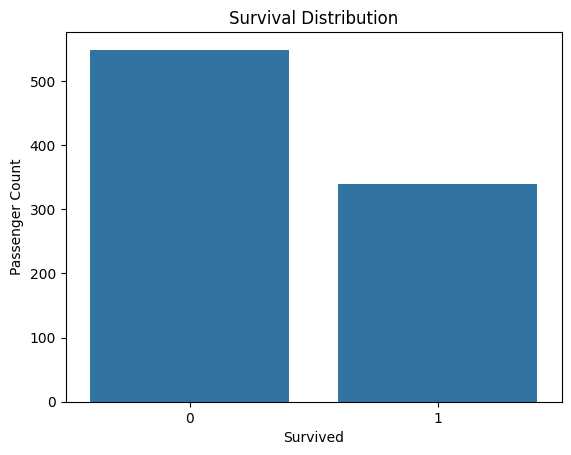

In [414]:
print('Survived')
sns.countplot(x="survived", data=df)

plt.title("Survival Distribution")
plt.xlabel("Survived")
plt.ylabel("Passenger Count")
plt.show()

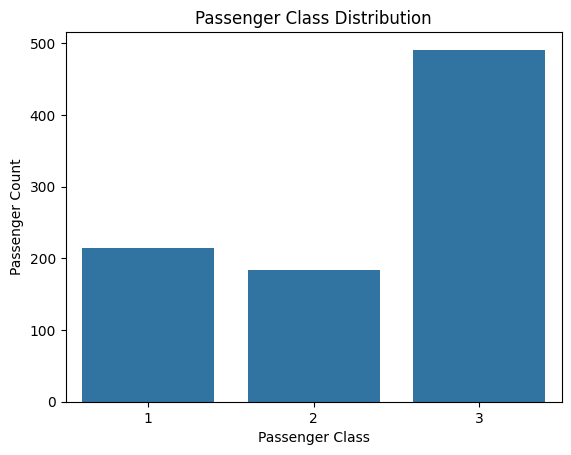

In [415]:
sns.countplot(x="pclass", data=df)

plt.title("Passenger Class Distribution")
plt.xlabel("Passenger Class")
plt.ylabel("Passenger Count")
plt.show()

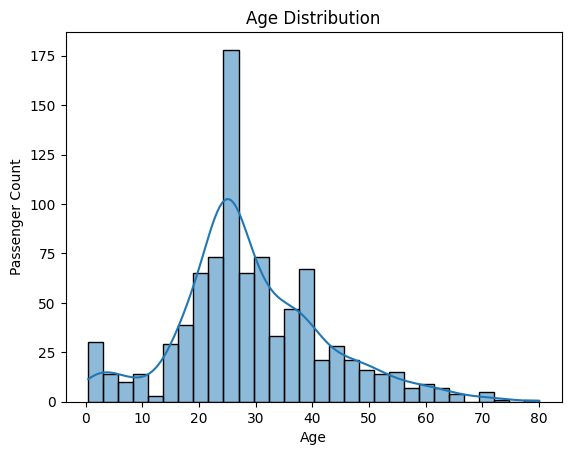

In [416]:
sns.histplot(df["age"].dropna(), bins=30, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Passenger Count")
plt.show()

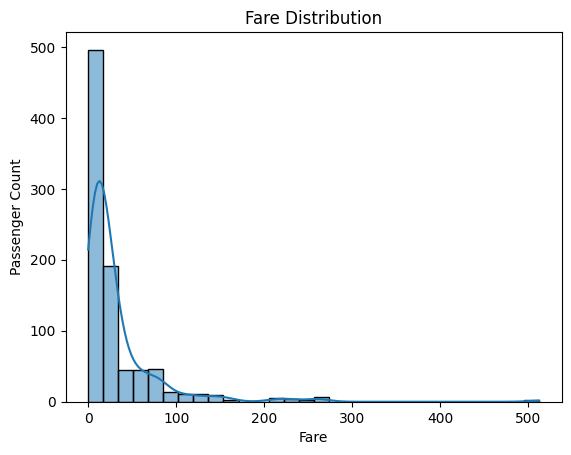

In [417]:
sns.histplot(df["fare"], bins=30, kde=True)

plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Passenger Count")
plt.show()

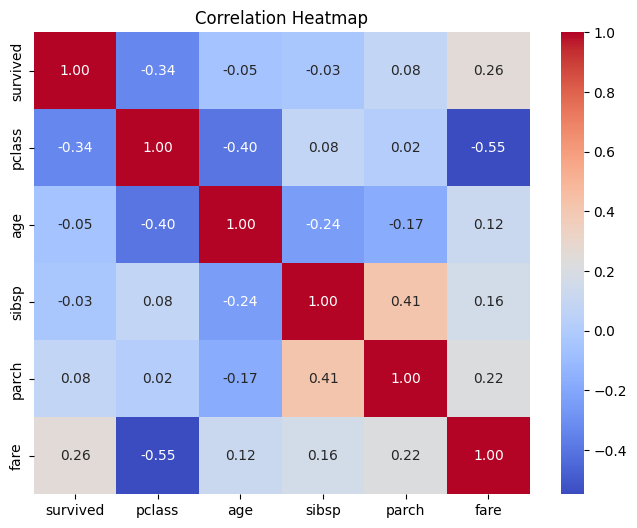

In [418]:
corr = df[["survived", "pclass", "age", "sibsp", "parch", "fare"]].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [419]:
from sklearn.neighbors import KNeighborsClassifier

In [420]:
df.head()

,survived,pclass,age,sibsp,parch,fare,adult_male,alone,male,man,woman,Queenstown,Southampton
0,0,3,22.0,1,0,7.2500,True,False,True,True,False,False,True
1,1,1,38.0,1,0,71.2833,False,False,False,False,True,False,False
2,1,3,26.0,0,0,7.9250,False,True,False,False,True,False,True
3,1,1,35.0,1,0,53.1000,False,False,False,False,True,False,True
4,0,3,35.0,0,0,8.0500,True,True,True,True,False,False,True


In [421]:
numerical_cols = ['age', 'sibsp', 'parch', 'fare']

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

df.head()

,survived,pclass,age,sibsp,parch,fare,adult_male,alone,male,man,woman,Queenstown,Southampton
0,0,3,-0.548070,0.431350,-0.474326,-0.500240,True,False,True,True,False,False,True
1,1,1,0.666757,0.431350,-0.474326,0.788947,False,False,False,False,True,False,False
2,1,3,-0.244363,-0.475199,-0.474326,-0.486650,False,True,False,False,True,False,True
3,1,1,0.438977,0.431350,-0.474326,0.422861,False,False,False,False,True,False,True
4,0,3,0.438977,-0.475199,-0.474326,-0.484133,True,True,True,True,False,False,True


In [422]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     889 non-null    int64  
 1   pclass       889 non-null    int64  
 2   age          889 non-null    float64
 3   sibsp        889 non-null    float64
 4   parch        889 non-null    float64
 5   fare         889 non-null    float64
 6   adult_male   889 non-null    bool   
 7   alone        889 non-null    bool   
 8   male         889 non-null    bool   
 9   man          889 non-null    bool   
 10  woman        889 non-null    bool   
 11  Queenstown   889 non-null    bool   
 12  Southampton  889 non-null    bool   
dtypes: bool(7), float64(4), int64(2)
memory usage: 54.7 KB


In [423]:
x = df[["pclass", "age", "sibsp", "parch", "fare"]]
y = df["survived"]

In [424]:
from sklearn.model_selection import cross_val_score

In [425]:
model = LogisticRegression()
scores = cross_val_score(model, x, y, cv=5)
print("Scores for each fold:", scores)
print(f"Logistic Regression's Mean Accuracy  : {scores.mean():.2f}")

Scores for each fold: [0.64044944 0.68539326 0.73033708 0.7247191  0.70056497]
Logistic Regression's Mean Accuracy  : 0.70


##KNN


In [426]:
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_scores = cross_val_score(knn_model, x, y, cv=5)
print("Scores for each fold:", knn_scores)
print(f"KNeighbors Classifier's Mean Accuracy  : {knn_scores.mean():.2f}")

Scores for each fold: [0.64044944 0.62921348 0.70786517 0.75280899 0.71751412]
KNeighbors Classifier's Mean Accuracy  : 0.69


## **DecisionTreeRegressor**

In [427]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)
import numpy as np

# Model
dt_model = DecisionTreeRegressor(random_state=42)

# 5-Fold Cross Validation
scores = cross_val_score(
    dt_model,
    x,
    y,
    cv=5,
    scoring="r2"
)

print("R² scores for each fold:", scores)
print(f"Mean CV R²: {scores.mean():.2f}")


# Train model on training data
dt_model.fit(x_train, y_train)

# Prediction
y_pred = dt_model.predict(x_test)

# Metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("MAE:", mae)
print("RMSE:", rmse)
print("Test R²:", r2)

R² scores for each fold: [-0.53727466 -0.55236969 -0.20959742 -0.48786833 -0.60925327]
Mean CV R²: -0.48
MSE: 0.1671261617422666
MAE: 0.1775905118601748
RMSE: 0.4088106673538089
Test R²: 0.25806006604427967


##RandomForestRegressor

In [428]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)
import numpy as np

# Model
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
scores = cross_val_score(
    model,
    x,
    y,
    cv=5,
    scoring="r2"
)

print("R² scores for each fold:", scores)
print(f"Mean CV R²: {scores.mean():.2f}")

model.fit(x_train, y_train)

y_pred = model.predict(x_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("MAE:", mae)
print("RMSE:", rmse)
print("Test R²:", r2)

R² scores for each fold: [-0.09506763 -0.00900941  0.10155436  0.08630633  0.078916  ]
Mean CV R²: 0.03
MSE: 0.12227839122097323
MAE: 0.20497464986457753
RMSE: 0.34968327272114863
Test R²: 0.45715727232095893


##***Comparison***

In [429]:
scores = cross_val_score(
    model, x, y, cv=5, scoring="accuracy"
)

knn_scores = cross_val_score(
    knn_model, x, y, cv=5, scoring="accuracy"
)

print("Logistic Regression:", scores.mean())
print("KNN:",knn_scores.mean())

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:978: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 140, in __call__
    score = scorer._score(
            ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 388, in _score
    return self._sign * self._score_func(y_true, y_pred, **scoring_kwargs)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/_param_validation.py", line 216, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py", line 227, in accuracy_score
    y_type, y_true, y_pred = _check_targets(y_true, y_pred)
                 

Logistic Regression: nan
KNN: 0.6895702405890941


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:978: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 140, in __call__
    score = scorer._score(
            ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 388, in _score
    return self._sign * self._score_func(y_true, y_pred, **scoring_kwargs)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/_param_validation.py", line 216, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py", line 227, in accuracy_score
    y_type, y_true, y_pred = _check_targets(y_true, y_pred)
                 

In [430]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "Decision Tree Regressor",
        "Random Forest Regressor"
    ],
    "Mean CV R²": [
        scores.mean(),
        scores.mean()
    ]
})

comparison

,Model,Mean CV R²
0,Decision Tree Regressor,NaN
1,Random Forest Regressor,NaN


##Include best parameters and CV scores.**bold text**

In [431]:
import pandas as pd
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV


model = DecisionTreeRegressor(random_state=42)

params = {
    "max_depth": [3, 5, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid = GridSearchCV(
    model,
    params,
    cv=5,
    scoring="r2"
)

grid.fit(x_train, y_train)



model = RandomForestRegressor(random_state=42)

params = {
    "n_estimators": [50, 100, 200],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5]
}

grid = GridSearchCV(
    model,
    params,
    cv=5,
    scoring="r2"
)

grid.fit(x_train, y_train)



comparison = pd.DataFrame({
    "Model": [
        "Decision Tree Regressor",
        "Random Forest Regressor"
    ],
    "Best Parameters": [
        grid.best_params_,
        grid.best_params_
    ],
    "Best CV R²": [
        grid.best_score_,
        grid.best_score_
    ]
})

comparison

,Model,Best Parameters,Best CV R²
0,Decision Tree Regressor,"{'max_depth': 5, 'min_samples_split': 5, 'n_es...",0.439011
1,Random Forest Regressor,"{'max_depth': 5, 'min_samples_split': 5, 'n_es...",0.439011
